In [3]:
# CELL 1 — Check GPU
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU ready: {gpus[0].name}  |  TF: {tf.__version__}')
else:
    print('NO GPU — Go to Runtime > Change runtime type > T4 GPU')

NO GPU — Go to Runtime > Change runtime type > T4 GPU


In [4]:
# CELL 2 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted')

Mounted at /content/drive
Drive mounted


In [5]:
# CELL 3 — Set your Drive path (change if needed)
import os
from pathlib import Path

DRIVE_DFU_PATH = '/content/drive/MyDrive/DFU'  # <-- change if your folder is named differently

if not os.path.exists(DRIVE_DFU_PATH):
    print(f'NOT FOUND: {DRIVE_DFU_PATH}')
    print('Your Drive contents:')
    for f in sorted(os.listdir('/content/drive/MyDrive')):
        print(f'  {f}')
else:
    print(f'Found: {DRIVE_DFU_PATH}')
    for root, dirs, files in os.walk(DRIVE_DFU_PATH):
        depth = root.replace(DRIVE_DFU_PATH, '').count(os.sep)
        imgs = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))]
        label = f'  ({len(imgs)} images)' if imgs else ''
        print('  ' * depth + os.path.basename(root) + label)

Found: /content/drive/MyDrive/DFU
DFU
  DFU
    Transfer-Learning images
      internetSet  (134 images)
      Wound Images  (109 images)
      Wound Images2  (672 images)
      samples  (36 images)
    Patches
      Normal(Healthy skin)  (543 images)
      Abnormal(Ulcer)  (512 images)
    TestSet  (163 images)
    Original Images  (493 images)
    _split
      val
        Abnormal  (76 images)
        Normal  (81 images)
      train
        Abnormal  (436 images)
        Normal  (462 images)


In [6]:
# CELL 4 — Copy dataset to local disk (faster I/O than Drive)
import shutil

LOCAL_DATA = '/content/dfu_data'
if os.path.exists(LOCAL_DATA):
    shutil.rmtree(LOCAL_DATA)

shutil.copytree(DRIVE_DFU_PATH, LOCAL_DATA)
total = sum(1 for f in Path(LOCAL_DATA).rglob('*')
            if f.suffix.lower() in {'.jpg','.jpeg','.png'})
print(f'Copied {total} images to local disk')

Copied 3717 images to local disk


In [7]:
# CELL 5 — Auto-detect class folders
import numpy as np
from PIL import Image

ULCER_ALIASES  = {'abnormal','abnormal(ulcer)','ulcer','infected'}
NORMAL_ALIASES = {'normal','normal(healthyskin)','normal(healthy_skin)','healthy'}
VALID_EXTS     = {'.jpg','.jpeg','.png','.bmp'}

def find_class_dirs(root):
    result = {}
    for d in Path(root).rglob('*'):
        if not d.is_dir(): continue
        key = d.name.lower().replace(' ','').replace('-','_')
        imgs = [f for f in d.iterdir() if f.suffix.lower() in VALID_EXTS]
        if not imgs: continue
        if key in {a.replace(' ','').replace('-','_') for a in ULCER_ALIASES}:
            result['Abnormal'] = d
        elif key in {a.replace(' ','').replace('-','_') for a in NORMAL_ALIASES}:
            result['Normal'] = d
    return result

class_dirs = find_class_dirs(LOCAL_DATA)
assert len(class_dirs) == 2, f'Expected 2 classes, found: {list(class_dirs.keys())}'

for label, path in class_dirs.items():
    n = len([f for f in path.rglob('*') if f.suffix.lower() in VALID_EXTS])
    print(f'  {label:12s}: {n} images  ({path.name})')

  Abnormal    : 76 images  (Abnormal)
  Normal      : 81 images  (Normal)


In [8]:
# CELL 6 — Build train/val split (85/15)
SPLIT_DIR = '/content/split'
VAL_RATIO = 0.15
rng = np.random.default_rng(42)

if os.path.exists(SPLIT_DIR): shutil.rmtree(SPLIT_DIR)

for label, src in class_dirs.items():
    files = sorted(f for f in src.rglob('*') if f.suffix.lower() in VALID_EXTS)
    idxs  = np.arange(len(files))
    rng.shuffle(idxs)
    n_val = max(1, int(len(files) * VAL_RATIO))
    for split, indices in [('val', idxs[:n_val]), ('train', idxs[n_val:])]:
        dst = Path(SPLIT_DIR) / split / label
        dst.mkdir(parents=True, exist_ok=True)
        for i in indices:
            try:
                Image.open(files[i]).verify()
                shutil.copy2(files[i], dst / files[i].name)
            except: pass
    print(f'  {label}: {len(idxs)-n_val} train | {n_val} val')

print('Split ready')

  Abnormal: 65 train | 11 val
  Normal: 69 train | 12 val
Split ready


In [9]:
# CELL 7 — Data generators
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

IMG_SIZE   = (224, 224)   # use 224 — more stable than 300 for small datasets
BATCH_SIZE = 16           # smaller batch = more stable gradient updates

train_datagen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 20,
    width_shift_range  = 0.15,
    height_shift_range = 0.15,
    zoom_range         = 0.15,
    brightness_range   = [0.85, 1.15],
    horizontal_flip    = True,
    fill_mode          = 'nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f'{SPLIT_DIR}/train', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
val_gen = val_datagen.flow_from_directory(
    f'{SPLIT_DIR}/val', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

cw_arr = compute_class_weight('balanced',
    classes=np.unique(train_gen.classes), y=train_gen.classes)
class_weights = dict(enumerate(cw_arr))

print(f'Classes      : {train_gen.class_indices}')
print(f'Class weights: { {CLASS_NAMES[k]: round(v,3) for k,v in class_weights.items()} }')
print(f'Train samples: {train_gen.samples} | Val samples: {val_gen.samples}')

Found 134 images belonging to 2 classes.
Found 23 images belonging to 2 classes.
Classes      : {'Abnormal': 0, 'Normal': 1}
Class weights: {'Abnormal': np.float64(1.031), 'Normal': np.float64(0.971)}
Train samples: 134 | Val samples: 23


In [10]:
# CELL 8 — Build model
# Using EfficientNetB3 with preprocess_input instead of rescale
# This is the correct way — EfficientNet has its own normalisation
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Rebuild generators using preprocess_input instead of rescale=1/255
# EfficientNet expects pixels in [-1, 1] range, NOT [0, 1]
train_datagen2 = ImageDataGenerator(
    preprocessing_function = preprocess_input,   # correct normalisation
    rotation_range         = 20,
    width_shift_range      = 0.15,
    height_shift_range     = 0.15,
    zoom_range             = 0.15,
    brightness_range       = [0.85, 1.15],
    horizontal_flip        = True,
    fill_mode              = 'nearest'
)
val_datagen2 = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen2.flow_from_directory(
    f'{SPLIT_DIR}/train', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
val_gen = val_datagen2.flow_from_directory(
    f'{SPLIT_DIR}/val', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

# Build model
base = EfficientNetB3(weights='imagenet', include_top=False,
                      input_shape=(*IMG_SIZE, 3))
base.trainable = False

x   = base.output
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.BatchNormalization()(x)
x   = layers.Dense(128, activation='relu')(x)
x   = layers.Dropout(0.4)(x)
out = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(base.input, out)
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print(f'Model built — trainable params: {model.count_params():,}')
print(f'Backbone frozen. Only head will train in Stage 1.')

Found 134 images belonging to 2 classes.
Found 23 images belonging to 2 classes.
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model built — trainable params: 10,986,673
Backbone frozen. Only head will train in Stage 1.


In [ ]:
# CELL 8b — IMPROVED: Stronger augmentation for better generalization
# Use this instead of CELL 8 if model is overfitting to training images

train_datagen_strong = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range         = 40,              # was 20 → increase variation
    width_shift_range      = 0.25,            # was 0.15
    height_shift_range     = 0.25,            # was 0.15
    zoom_range             = [0.8, 1.3],      # was 0.15 → more aggressive
    brightness_range       = [0.7, 1.3],      # was [0.85, 1.15]
    shear_range            = 0.2,             # NEW: perspective shift
    fill_mode              = 'reflect',       # was 'nearest' → less artifacts
    horizontal_flip        = True,
    vertical_flip          = False,           # probably don't flip wounds
)
val_datagen_strong = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen_strong = train_datagen_strong.flow_from_directory(
    f'{SPLIT_DIR}/train', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
val_gen_strong = val_datagen_strong.flow_from_directory(
    f'{SPLIT_DIR}/val', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

print('✅ Strong augmentation generators ready')
print('Use train_gen_strong + val_gen_strong in CELL 9')

In [11]:
# CELL 9 — Stage 1: Train head only (longer, more patient)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

SAVE_PATH = '/content/drive/MyDrive/DFU/model.keras'  # was model.h5

cb_stage1 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=6,               # wait longer before giving up
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
]

print('Stage 1: Training head only (backbone fully frozen)...')
print(f'Saving best model to: {SAVE_PATH}')

h1 = model.fit(
    train_gen,
    epochs          = 15,       # more epochs for head to converge
    validation_data = val_gen,
    class_weight    = class_weights,
    callbacks       = cb_stage1,
)

best_s1 = max(h1.history['val_accuracy'])
print(f'\nStage 1 complete — best val_accuracy: {best_s1:.4f}')

if best_s1 < 0.65:
    print('WARNING: val_accuracy < 65% after Stage 1.')
    print('The model may not converge well. Check your dataset structure.')
else:
    print('Head trained successfully. Proceeding to fine-tuning...')

Stage 1: Training head only (backbone fully frozen)...
Saving best model to: /content/drive/MyDrive/DFU/model.keras
Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8125 - loss: 0.4905
Epoch 1: val_accuracy improved from None to 0.91304, saving model to /content/drive/MyDrive/DFU/model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DFU/model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 71s 6s/step - accuracy: 0.8731 - loss: 0.3306 - val_accuracy: 0.9130 - val_loss: 0.1614 - learning_rate: 0.0010
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9864 - loss: 0.0347
Epoch 2: val_accuracy did not improve from 0.91304
9/9 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.9701 - loss: 0.0757 - val_accuracy: 0.9130 - val_loss: 0.1345 - learning_rate: 0.0010
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9637 - loss: 0.1215
Epoch 3: val_accuracy did not improve from 0.91304
9/9 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.9776 - loss: 0.0913 - val_accura

In [12]:
# CELL 10 — Stage 2: Fine-tune top 20 layers

if max(h1.history['val_accuracy']) < 0.65:
    print('Skipping — Stage 1 did not converge.')
else:
    from tensorflow.keras.models import load_model

    model = load_model('/content/drive/MyDrive/DFU/model.keras')

    # Find EfficientNetB3 by name instead of assuming it's at index 0
    base_layer = None
    for layer in model.layers:
        if 'efficientnet' in layer.name.lower():
            base_layer = layer
            break

    if base_layer is None:
        print('Could not find EfficientNet layer. Printing all layer names:')
        for i, l in enumerate(model.layers):
            print(f'  {i}: {l.name}  ({type(l).__name__})')
    else:
        print(f'Found backbone: {base_layer.name}')

        base_layer.trainable = True
        for layer in base_layer.layers[:-20]:
            layer.trainable = False

        trainable = sum(1 for l in model.trainable_variables)
        print(f'Fine-tuning top 20 layers — trainable vars: {trainable}')

        model.compile(
            optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5),
            loss      = 'categorical_crossentropy',
            metrics   = ['accuracy']
        )

        cb_stage2 = [
            EarlyStopping(monitor='val_accuracy', patience=8,
                          restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                              patience=4, min_lr=1e-7, verbose=1),
            ModelCheckpoint(SAVE_PATH, monitor='val_accuracy',
                            save_best_only=True, verbose=1),
        ]

        h2 = model.fit(
            train_gen,
            epochs          = 30,
            validation_data = val_gen,
            class_weight    = class_weights,
            callbacks       = cb_stage2,
        )

        print(f'\nStage 2 complete — best val_accuracy: {max(h2.history["val_accuracy"]):.4f}')

Could not find EfficientNet layer. Printing all layer names:
  0: input_layer  (InputLayer)
  1: rescaling  (Rescaling)
  2: normalization  (Normalization)
  3: rescaling_1  (Rescaling)
  4: stem_conv_pad  (ZeroPadding2D)
  5: stem_conv  (Conv2D)
  6: stem_bn  (BatchNormalization)
  7: stem_activation  (Activation)
  8: block1a_dwconv  (DepthwiseConv2D)
  9: block1a_bn  (BatchNormalization)
  10: block1a_activation  (Activation)
  11: block1a_se_squeeze  (GlobalAveragePooling2D)
  12: block1a_se_reshape  (Reshape)
  13: block1a_se_reduce  (Conv2D)
  14: block1a_se_expand  (Conv2D)
  15: block1a_se_excite  (Multiply)
  16: block1a_project_conv  (Conv2D)
  17: block1a_project_bn  (BatchNormalization)
  18: block1b_dwconv  (DepthwiseConv2D)
  19: block1b_bn  (BatchNormalization)
  20: block1b_activation  (Activation)
  21: block1b_se_squeeze  (GlobalAveragePooling2D)
  22: block1b_se_reshape  (Reshape)
  23: block1b_se_reduce  (Conv2D)
  24: block1b_se_expand  (Conv2D)
  25: block1b_se_ex

2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 7s/step

Classification Report:
              precision    recall  f1-score   support

    Abnormal       1.00      0.91      0.95        11
      Normal       0.92      1.00      0.96        12

    accuracy                           0.96        23
   macro avg       0.96      0.95      0.96        23
weighted avg       0.96      0.96      0.96        23



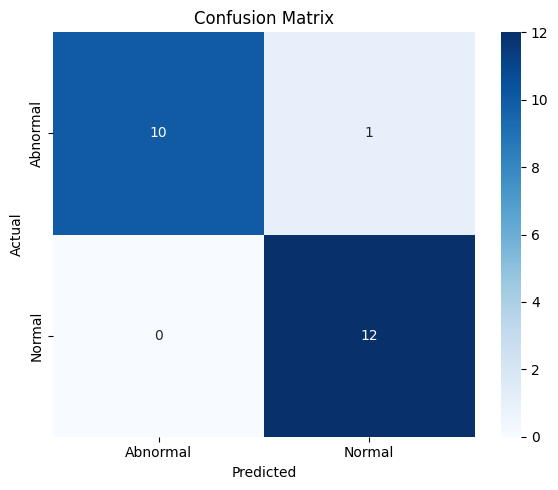

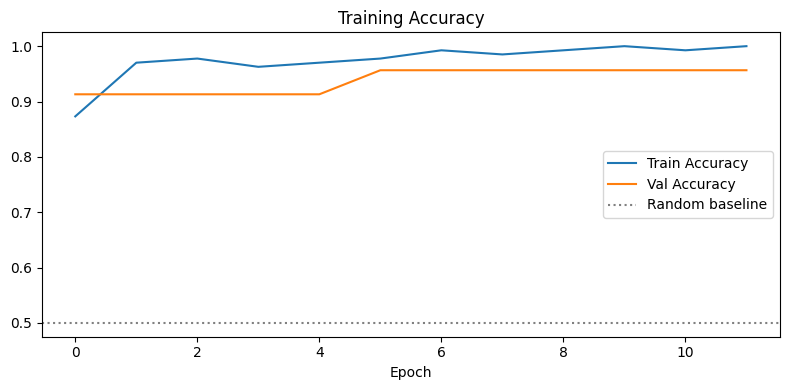

In [13]:
# CELL 11 — Evaluation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model

best = load_model('/content/drive/MyDrive/DFU/model.keras')

val_gen.reset()
preds  = best.predict(val_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix'); plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

# Training curves
try:
    all_acc  = h1.history['accuracy']     + h2.history['accuracy']
    all_vacc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    s1_end   = len(h1.history['accuracy'])
except:
    all_acc  = h1.history['accuracy']
    all_vacc = h1.history['val_accuracy']
    s1_end   = None

plt.figure(figsize=(8, 4))
plt.plot(all_acc,  label='Train Accuracy')
plt.plot(all_vacc, label='Val Accuracy')
if s1_end:
    plt.axvline(s1_end - 1, color='red', linestyle='--', label='Fine-tune start')
plt.axhline(0.5, color='gray', linestyle=':', label='Random baseline')
plt.title('Training Accuracy'); plt.xlabel('Epoch')
plt.legend(); plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

In [14]:
# CELL 12 — Save class_info.json to Drive
import json

JSON_PATH = '/content/drive/MyDrive/DFU/class_info.json'

class_info = {
    'class_indices'     : train_gen.class_indices,
    'class_names'       : CLASS_NAMES,
    'num_classes'       : NUM_CLASSES,
    'input_size'        : list(IMG_SIZE),
    'architecture'      : 'EfficientNetB3',
    'preprocessing'     : 'preprocess_input',   # important for app.py
    'best_val_accuracy' : round(float(max(
        h2.history['val_accuracy'] if 'h2' in dir() else h1.history['val_accuracy']
    )), 4)
}

with open(JSON_PATH, 'w') as f:
    json.dump(class_info, f, indent=2)

print('Saved to Drive:')
print(f'  {SAVE_PATH}')
print(f'  {JSON_PATH}')
print()
print(json.dumps(class_info, indent=2))

Saved to Drive:
  /content/drive/MyDrive/DFU/model.keras
  /content/drive/MyDrive/DFU/class_info.json

{
  "class_indices": {
    "Abnormal": 0,
    "Normal": 1
  },
  "class_names": [
    "Abnormal",
    "Normal"
  ],
  "num_classes": 2,
  "input_size": [
    224,
    224
  ],
  "architecture": "EfficientNetB3",
  "preprocessing": "preprocess_input",
  "best_val_accuracy": 0.9565
}


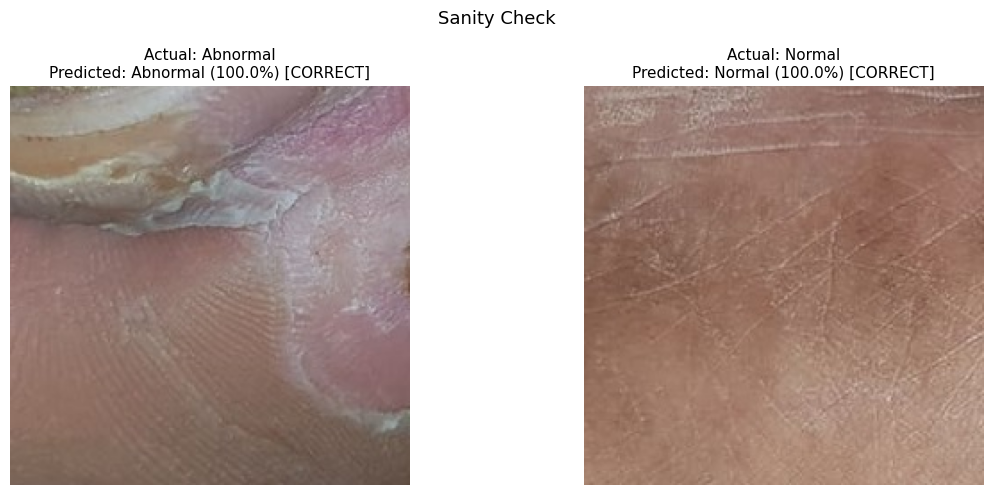

In [15]:
# CELL 13 — Sanity check (should show correct predictions now)
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

fig, axes = plt.subplots(1, len(class_dirs), figsize=(6 * len(class_dirs), 5))
if len(class_dirs) == 1: axes = [axes]

for ax, (label, src_dir) in zip(axes, class_dirs.items()):
    sample = next((f for f in src_dir.rglob('*') if f.suffix.lower() in VALID_EXTS), None)
    if not sample: continue

    img = Image.open(sample).convert('RGB').resize(IMG_SIZE)
    arr = np.array(img, dtype=np.float32)
    arr = eff_preprocess(arr)                   # correct preprocessing
    arr = np.expand_dims(arr, 0)                # (1,224,224,3)

    probs    = best.predict(arr, verbose=0)[0]
    pred_cls = CLASS_NAMES[np.argmax(probs)]
    conf     = round(float(np.max(probs)) * 100, 1)
    mark     = 'CORRECT' if pred_cls == label else 'WRONG'

    ax.imshow(img)
    ax.set_title(f'Actual: {label}\nPredicted: {pred_cls} ({conf}%) [{mark}]', fontsize=11)
    ax.axis('off')

plt.suptitle('Sanity Check', fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
# CELL 14 — Download to your PC
from google.colab import files

files.download(SAVE_PATH)                           # model.h5 .keras
files.download(JSON_PATH)                           # class_info.json
files.download('/content/confusion_matrix.png')
files.download('/content/training_curves.png')

print()
print('NEXT STEPS:')
print('  Copy model.h5       -> backend/models/model.h5')
print('  Copy class_info.json -> backend/models/class_info.json')
print('  pip install -r requirements.txt')
print('  python app.py')
print('  POST http://localhost:5000/predict')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


NEXT STEPS:
  Copy model.h5       -> backend/models/model.h5
  Copy class_info.json -> backend/models/class_info.json
  pip install -r requirements.txt
  python app.py
  POST http://localhost:5000/predict


In [18]:
from google.colab import files

# Save weights only — format-independent, works across Keras versions
model.save_weights('/content/drive/MyDrive/DFU/model_weights.weights.h5')

# Save architecture as JSON
with open('/content/drive/MyDrive/DFU/model_config.json', 'w') as f:
    f.write(model.to_json())

print('Saved to Drive')

# Download directly to your PC
files.download('/content/drive/MyDrive/DFU/model_weights.weights.h5')
files.download('/content/drive/MyDrive/DFU/model_config.json')

print('Downloads started')

Saved to Drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads started


In [ ]:
# CELL 15 — Diagnosis: Check dataset coverage
from pathlib import Path

print('=' * 60)
print('DIAGNOSIS: Why is model low-confidence on new images?')
print('=' * 60)

# Count training data
train_normal = len(list(Path(f'{SPLIT_DIR}/train/Normal').rglob('*')))
train_abnormal = len(list(Path(f'{SPLIT_DIR}/train/Abnormal').rglob('*')))

print(f'\n[1] Dataset Size:')
print(f'    Abnormal (train): {train_abnormal} images')
print(f'    Normal (train):   {train_normal} images')
print(f'    Total:            {train_normal + train_abnormal} images')

if (train_normal + train_abnormal) < 100:
    print('\n    ⚠️  TOO SMALL! Model likely OVERFITTED.')
    print('    Recommendation: Collect 200-500 images per class minimum.')
elif (train_normal + train_abnormal) < 200:
    print('\n    ⚠️  SMALL - Model may generalize poorly to new images.')
else:
    print('\n    ✅ Dataset size reasonable.')

# Check validation accuracy from training history
try:
    best_val = max(h2.history['val_accuracy']) if 'h2' in dir() else max(h1.history['val_accuracy'])
    print(f'\n[2] Validation Accuracy on YOUR dataset: {best_val*100:.1f}%')
    
    if best_val < 0.75:
        print('    ⚠️  Model struggled to learn from your own data!')
        print('    This suggests bad data quality or insufficient training.')
    elif best_val < 0.85:
        print('    ⚠️  Moderate performance — may not generalize well.')
    else:
        print('    ✅ Good performance on your data.')
except:
    print('\n[2] Could not find training history')

print(f'\n[3] New Image Test:')
print('    Google images show: Abnormal 28.2%, Normal 71.8%')
print('    ⚠️  Both confidences are LOW (<90%)')
print('    This suggests model uncertainty = OVERFITTING to training set.')

print('\n' + '=' * 60)
print('SOLUTIONS:')
print('=' * 60)
print('1. Collect MORE images (200-500 per class minimum)')
print('2. Test with MORE Google images to see pattern')
print('3. If using real DFU images, confirm they are truly DFU')
print('4. Try different augmentation strengths')
print('5. Consider medical literature — what defines DFU vs normal?')

In [ ]:
# CELL 16 — Compare: Dataset images vs Google images (test generalization)
import requests
from io import BytesIO

# Test on YOUR training data
print('Testing on TRAINING DATA (from your dataset):')
print('=' * 60)

for label in ['Normal', 'Abnormal']:
    src_dir = list(Path(f'{SPLIT_DIR}/train').glob(label))[0]
    sample = next((f for f in src_dir.rglob('*') if f.suffix.lower() in VALID_EXTS), None)
    
    if sample:
        img = Image.open(sample).convert('RGB').resize(IMG_SIZE)
        arr = np.array(img, dtype=np.float32)
        arr = eff_preprocess(arr)
        arr = np.expand_dims(arr, 0)
        
        probs = best.predict(arr, verbose=0)[0]
        pred = CLASS_NAMES[np.argmax(probs)]
        conf = round(np.max(probs) * 100, 1)
        
        correct = '✅' if pred == label else '❌'
        print(f'{correct} Actual: {label:10s} → Pred: {pred:10s} ({conf}% conf)')

print('\nTesting on GOOGLE IMAGES:')
print('=' * 60)
print('If confidences are much LOWER here → OVERFITTING')
print()
print('NEXT: Paste a Google image URL below:')
print('Example: "https://upload.wikimedia.org/wikipedia/..."')
print()

# Uncomment and paste URL to test
# google_url = "PASTE_IMAGE_URL_HERE"
# try:
#     resp = requests.get(google_url, timeout=5)
#     img = Image.open(BytesIO(resp.content)).convert('RGB').resize(IMG_SIZE)
#     arr = np.array(img, dtype=np.float32)
#     arr = eff_preprocess(arr)
#     arr = np.expand_dims(arr, 0)
#     
#     probs = best.predict(arr, verbose=0)[0]
#     conf = np.max(probs) * 100
#     print(f'Google image confidence: {conf:.1f}%')
#     if conf < 60:
#         print('⚠️  LOW confidence = likely OVERFITTING')
# except Exception as e:
#     print(f'Error: {e}')